# Paso 1: Preparar entorno

In [51]:

!pip install requests pandas matplotlib seaborn sqlalchemy
import requests 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3
from sqlalchemy import create_engine
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Paso 2 definir paises e indicadores


Seleccion del dataset
Elige 5 paises (ISO3) que te interesen.

In [ ]:
#countries = ["AFG", "AFE", "ARB", "ARG", "ZAF"] use estos antes pero me daba raro el grafico, probé con ambos igualmente.
countries = ["ARG", "BRA", "CHL", "COL", "MEX"]

Elige los indicadores que quieras analizar.
    Recomendacion de indicadores (opcional):
SP.POP.TOTL: Poblacion total
NY.GDP.PCAP.CD: PIB per capita (USD actuales)
EN.ATM.CO2E.PC: Emisiones de CO2 per capita (toneladas metricas)
SP.DYN.LE00.IN: Esperanza de vida al nacer (anios)

In [53]:
ind_population = "SP.POP.TOTL"
ind_gdp = "NY.GDP.PCAP.CD"
ind_life = "SP.DYN.LE00.IN"

In [54]:
url = "https://api.worldbank.org/v2/country/ABW/indicator/SP.POP.TOTL"
params = {
     "format": "json",
     "per_page": 65,
     "page": 1
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
data = response.json()
print(data)

print("Metadatos:", data[0])
print("-----------")
print("Primer elemento:", data[1][0])

[{'page': 1, 'pages': 2, 'per_page': 65, 'total': 66, 'sourceid': '2', 'lastupdated': '2026-02-24'}, [{'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'AW', 'value': 'Aruba'}, 'countryiso3code': 'ABW', 'date': '2025', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'AW', 'value': 'Aruba'}, 'countryiso3code': 'ABW', 'date': '2024', 'value': 107995, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'AW', 'value': 'Aruba'}, 'countryiso3code': 'ABW', 'date': '2023', 'value': 107359, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'}, 'country': {'id': 'AW', 'value': 'Aruba'}, 'countryiso3code': 'ABW', 'date': '2022', 'value': 107310, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'SP.POP.TOTL', 'value':

## Paso 3: Descargar datos

Descarga series temporales 2010-2024 para los paises e indicadores que elegiste.

Objetivo:
Consumir la API para varios paises e indicadores
Manejar paginacion cuando aplique
Guardar respuestas en una estructura temporal (lista de diccionarios)

Datos indicador: poblacion 

In [55]:
population_data = []

for country in countries:
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{ind_population}"
    page = 1

    while True:
        params = {
            "format": "json",
            "per_page": 100,
            "page": page,
            "date": "2010:2024"
        }

        response = requests.get(url, params=params)
        payload = response.json()

        if len(payload) < 2:
            break

        for entry in payload[1]:
            population_data.append({
                "country": entry["country"]["id"],
                "year": int(entry["date"]),
                "value": entry["value"]
            })

        if page >= payload[0]["pages"]:
            break

        page += 1


Datos indicador: PIB PER CAPITA 

In [56]:
gdp_data = []
for country in countries:
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{ind_gdp}"
    page = 1

    while True:
        params = {
            "format": "json",
            "per_page": 100,
            "page": page,
            "date": "2010:2024"
        }

        response = requests.get(url, params=params)
        payload = response.json()

        if len(payload) < 2:
            break

        for entry in payload[1]:
            gdp_data.append({
                "country": entry["country"]["id"],
                "year": int(entry["date"]),
                "value": entry["value"]
            })

        if page >= payload[0]["pages"]:
            break

        page += 1


Datos indicador: Esperanza de vida 

In [57]:
life_data = []
for country in countries:
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{ind_life}"
    page = 1

    while True:
        params = {
            "format": "json",
            "per_page": 100,
            "page": page,
            "date": "2010:2024"
        }

        response = requests.get(url, params=params)
        payload = response.json()

        if len(payload) < 2:
            break

        for entry in payload[1]:
            life_data.append({
                "country": entry["country"]["id"],
                "year": int(entry["date"]),
                "value": entry["value"]
            })

        if page >= payload[0]["pages"]:
            break

        page += 1

life_data


[{'country': 'AR', 'year': 2024, 'value': None},
 {'country': 'AR', 'year': 2023, 'value': 77.395},
 {'country': 'AR', 'year': 2022, 'value': 75.806},
 {'country': 'AR', 'year': 2021, 'value': 73.948},
 {'country': 'AR', 'year': 2020, 'value': 75.878},
 {'country': 'AR', 'year': 2019, 'value': 76.847},
 {'country': 'AR', 'year': 2018, 'value': 76.77},
 {'country': 'AR', 'year': 2017, 'value': 76.543},
 {'country': 'AR', 'year': 2016, 'value': 76.105},
 {'country': 'AR', 'year': 2015, 'value': 76.6},
 {'country': 'AR', 'year': 2014, 'value': 76.268},
 {'country': 'AR', 'year': 2013, 'value': 75.829},
 {'country': 'AR', 'year': 2012, 'value': 75.802},
 {'country': 'AR', 'year': 2011, 'value': 76.1},
 {'country': 'AR', 'year': 2010, 'value': 75.68},
 {'country': 'BR', 'year': 2024, 'value': None},
 {'country': 'BR', 'year': 2023, 'value': 75.848},
 {'country': 'BR', 'year': 2022, 'value': 74.872},
 {'country': 'BR', 'year': 2021, 'value': 73.038},
 {'country': 'BR', 'year': 2020, 'value':

## Paso 4: Transformar respuesta a DataFrames


Datos indicador: poblacion 

In [58]:
df_population = pd.DataFrame(population_data)
df_population["year"] = df_population["year"].astype(int)
df_population["value"] = pd.to_numeric(df_population["value"], errors="coerce")
df_population = df_population.dropna(subset=["value"])
df_population.head(40)

,country,year,value
0,AR,2024,45696159
1,AR,2023,45538401
2,AR,2022,45407904
3,AR,2021,45312281
4,AR,2020,45191965
5,AR,2019,44973465
6,AR,2018,44654882
7,AR,2017,44288894
8,AR,2016,43900313
9,AR,2015,43477012


Datos indicador: PIB PER CAPITA 

In [59]:
df_gdp = pd.DataFrame(gdp_data)
df_gdp["value"] = pd.to_numeric(df_gdp["value"], errors="coerce")
df_gdp = df_gdp.dropna(subset=["value"])
df_gdp

,country,year,value
0,AR,2024,13969.783660
1,AR,2023,14261.846567
2,AR,2022,13962.189409
3,AR,2021,10738.017922
4,AR,2020,8535.599380
...,...,...,...
70,MX,2014,11391.377350
71,MX,2013,11216.800851
72,MX,2012,10744.133524
73,MX,2011,10664.494403


Datos indicador: Esperanza de vida 

In [60]:
df_life = pd.DataFrame(life_data)
df_life["value"] = pd.to_numeric(df_life["value"], errors="coerce")
df_life = df_life.dropna(subset=["value"])
df_life

,country,year,value
1,AR,2023,77.395
2,AR,2022,75.806
3,AR,2021,73.948
4,AR,2020,75.878
5,AR,2019,76.847
...,...,...,...
70,MX,2014,74.404
71,MX,2013,74.289
72,MX,2012,74.128
73,MX,2011,73.921


# Paso 5: Analisis y visualizaciones


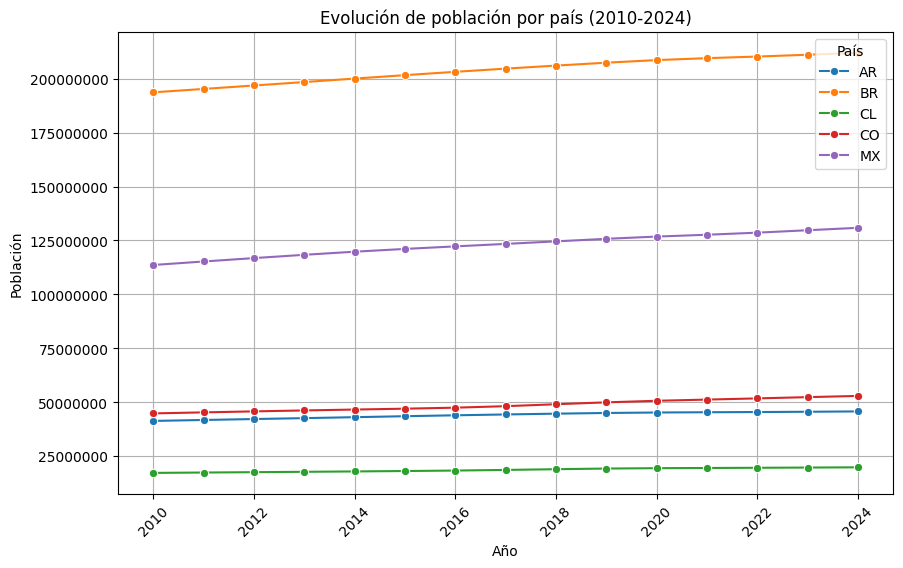

In [61]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df_population, x="year", y="value", hue="country", marker="o")

plt.title("Evolución de población por país (2010-2024)")
plt.xlabel("Año")
plt.ylabel("Población")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="País")

plt.ticklabel_format(style='plain', axis='y')  # <- esto quita la notación científica

plt.show()



En el grafico lineal podemos observar para los 5 paises escogidos todos han aunentado su poblacion en los ultimos 14 años, unos en mayor medida que otros. 

# Otro grafico 


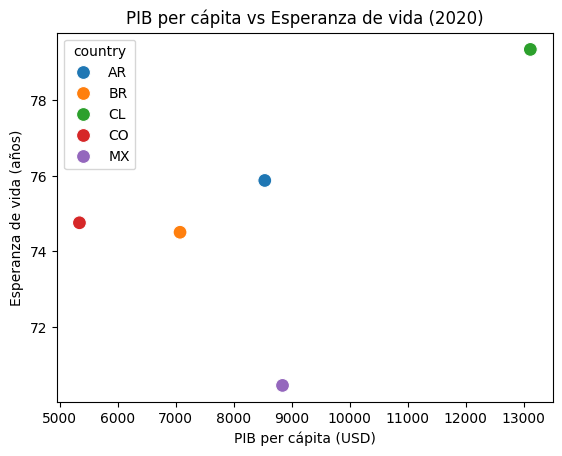

In [65]:
df_merge = pd.merge(
    df_gdp[df_gdp["year"] == 2020],
    df_life[df_life["year"] == 2020],
    on=["country", "year"],
    suffixes=("_gdp", "_life")
)

sns.scatterplot(data=df_merge, x="value_gdp", y="value_life", hue="country", s=100)

plt.title("PIB per cápita vs Esperanza de vida (2020)")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Esperanza de vida (años)")
plt.show()


En el gráfrico PIB per cápita vs Esperanza de vida del año 2020, se observa que a mayor pib per capita mayor esperanza de vida en años. 

 # Paso 6: Cargar resultados a base de datos SQL

In [63]:


conn = sqlite3.connect("world_bank_analysis.db")

df_population.to_sql("indicator_population", conn, if_exists="replace", index=False)
df_gdp.to_sql("indicator_gdp", conn, if_exists="replace", index=False)
df_life.to_sql("indicator_life", conn, if_exists="replace", index=False)

conn.close()



In [64]:
conn = sqlite3.connect("world_bank_analysis.db")

pd.read_sql("SELECT * FROM indicator_population limit 20", conn)


,country,year,value
0,AR,2024,45696159
1,AR,2023,45538401
2,AR,2022,45407904
3,AR,2021,45312281
4,AR,2020,45191965
5,AR,2019,44973465
6,AR,2018,44654882
7,AR,2017,44288894
8,AR,2016,43900313
9,AR,2015,43477012
